# Module 12 - Programming Assignment

## General Directions

1. You must follow the Programming Requirements outlined on Canvas.
2. The Notebook should be cleanly and fully executed before submission.
3. You should change the name of this file to be your JHED id. For example, `jsmith299.ipynb` although Canvas will change it to something else...
4. You must follow the Programming Requirments for this course.

<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Important</strong>
    <p>
        You should always read the entire assignment before beginning your work, so that you know in advance what the requested output will be and can plan your implementation accordingly.
    </p>
</div>

<div style="color: white; background: #C83F49; margin:20px; padding: 20px;">
    <strong>Academic Integrity and Copyright</strong>
    <p>You are not permitted to consult outside sources (Stackoverflow, YouTube, ChatGPT, etc.) or use "code assistance" (Co-Pilot, etc) to complete this assignment. By submitting this assignment for grading, you certify that the submission is 100% your own work, based on course materials, group interactions, instructor guidance. You agree to comply by the requirements set forth in the Syllabus, including, by reference, the JHU KSAS/WSE Graduate Academic Misconduct Policy.</p>
    <p>Sharing this assignment either directly (e.g., email, github, homework site) or indirectly (e.g., ChatGPT, machine learning platform) is a violation of the copyright. Additionally, all such sharing is a violation the Graduate Academic Misconduct Policy (facilitating academic dishonesty is itself academic dishonesty), even after you graduate.</p>
    <p>If you have questions or if you're unsure about the policy, ask via Canvas Inbox. In this case, being forgiven is <strong>not</strong> easier than getting permission and ignorance is not an excuse.</p>
    <p>This assignment is copyright (&copy Johns Hopkins University &amp; Stephyn G. W. Butcher). All rights reserved.</p>
</div>

## k Nearest Neighbors and Model Evaluation

In this programming assignment you will use k Nearest Neighbors (kNN) to build a "model" that will estimate the compressive strength of various types of concrete. This assignment has several objectives:

1. Implement the kNN algorithm with k=9. Remember...the data + distance function is the model in kNN. In addition to asserts that unit test your code, you should "test drive" the model, showing output that a non-technical person could interpret.

2. You are going to compare the kNN model above against the baseline model described in the course notes (the mean of the training set's target variable). You should use 10 fold cross validation and Mean Squared Error (MSE):

$$MSE = \frac{1}{n}\sum^n_i (y_i - \hat{y}_i)^2$$

as the evaluation metric ("error"). Refer to the course notes for the format your output should take. Don't forget a discussion of the results.

3. use validation curves to tune a *hyperparameter* of the model. 
In this case, the hyperparameter is *k*, the number of neighbors. Don't forget a discussion of the results.

4. evaluate the *generalization error* of the new model.
Because you may have just created a new, better model, you need a sense of its generalization error, calculate that. Again, what would you like to see as output here? Refer to the course notes. Don't forget a discussion of the results. Did the new model do better than either model in Q2?

5. pick one of the "Choose Your Own Adventure" options.

Refer to the "course notes" for this module for most of this assignment.
Anytime you just need test/train split, use fold index 0 for the test set and the remainder as the training set.
Discuss any results.

## Load the Data

The function `parse_data` loads the data from the specified file and returns a List of Lists. The outer List is the data set and each element (List) is a specific observation. Each value of an observation is for a particular measurement. This is what we mean by "tidy" data.

The function also returns the *shuffled* data because the data might have been collected in a particular order that *might* bias training.

In [1]:
import random
from typing import List, Dict, Tuple, Callable, NamedTuple
from math import sqrt, inf
import matplotlib.pyplot as plt

In [2]:
def parse_data(file_name: str) -> List[List]:
    data = []
    file = open(file_name, "r")
    for line in file:
        datum = [float(value) for value in line.rstrip().split(",")]
        data.append(datum)
    random.shuffle(data)
    return data

In [3]:
data = parse_data("concrete_compressive_strength-3.csv")

In [4]:
data[0]

[141.9, 166.6, 129.7, 173.5, 10.9, 882.6, 785.3, 28.0, 44.61]

In [5]:
len(data)

1030

There are 1,030 observations and each observation has 8 measurements. The data dictionary for this data set tells us the definitions of the individual variables (columns/indices):

| Index | Variable | Definition |
|-------|----------|------------|
| 0     | cement   | kg in a cubic meter mixture |
| 1     | slag     | kg in a cubic meter mixture |
| 2     | ash      | kg in a cubic meter mixture |
| 3     | water    | kg in a cubic meter mixture |
| 4     | superplasticizer | kg in a cubic meter mixture |
| 5     | coarse aggregate | kg in a cubic meter mixture |
| 6     | fine aggregate | kg in a cubic meter mixture |
| 7     | age | days |
| 8     | concrete compressive strength | MPa |

The target ("y") variable is a Index 8, concrete compressive strength in (Mega?) [Pascals](https://en.wikipedia.org/wiki/Pascal_(unit)).

## Train/Test Splits - n folds

With n fold cross validation, we divide our data set into n subgroups called "folds" and then use those folds for training and testing. You pick n based on the size of your data set. If you have a small data set--100 observations--and you used n=10, each fold would only have 10 observations. That's probably too small. You want at least 30. At the other extreme, we generally don't use n > 10.

With 1,030 observations, n = 10 is fine so we will have 10 folds.
`create_folds` will take a list (xs) and split it into `n` equal folds with each fold containing one-tenth of the observations.

In [6]:
def create_folds(xs: List, n: int) -> List[List[List]]:
    k, m = divmod(len(xs), n)
    # be careful of generators...
    return list(xs[i * k + min(i, m) : (i + 1) * k + min(i + 1, m)] for i in range(n))

In [7]:
folds = create_folds(data, 10)

In [8]:
len(folds)

10

We always use one of the n folds as a test set (and, sometimes, one of the folds as a *pruning* set but not for kNN), and the remaining folds as a training set.
We need a function that'll take our n folds and return the train and test sets:

In [9]:
def create_train_test(folds: List[List[List]], index: int) -> Tuple[List[List], List[List]]:
    training = []
    test = []
    for i, fold in enumerate(folds):
        if i == index:
            test = fold
        else:
            training = training + fold
    return training, test

We can test the function to give us a train and test datasets where the test set is the fold at index 0:

In [10]:
train, test = create_train_test(folds, 0)

In [11]:
len(train)

927

In [12]:
len(test)

103

## Answers

Answer the questions above in the space provided below, adding cells as you need to.
Put everything in the helper functions and document them.
Document everything (what you're doing and why).
If you're not sure what format the output should take, refer to the course notes and what they do for that particular topic/algorithm.

## Problem 1: kNN

Implement k Nearest Neighbors algorithm with k = 9. (Do not confuse the algorithm with evaluating the algorithm. We just want the algorithm here.)

In [13]:
def average_label(nearest: List[Tuple[float, List[float]]], label_idx: int = -1):
    return sum([example[label_idx] for _, example in nearest]) / len(nearest)

In [14]:
def euclidean_distance(example: List[float], query: List[float], label_idx: int = -1):
    label_idx = len(example) - 1 if label_idx < 0 else label_idx
    distance = sum([(x - y) ** 2 for i, (x, y) in enumerate(zip(example, query)) if i != label_idx])
    return sqrt(distance)

In [15]:
def pretty_print_distances(distances: List[Tuple[float, List[float]]], k: int):
    for i, (dist, example) in enumerate(distances):
        if i == k:
            print("-----" * 10)
        print(i, example, dist)
    return

In [16]:
def knn(
    dataset: List[List[float]], query: List[float], k: int, label_idx: int = -1, distance: Callable = euclidean_distance, processing: Callable = average_label, debug: bool = False
) -> float:
    distances = [(distance(example, query, label_idx), example) for example in dataset]
    distances = sorted(distances, key=lambda x: x[0])
    pretty_print_distances(distances, k) if debug else None
    return processing(distances[:k])

In [17]:
result = knn(train, test[0], 9)
print(f"{result:.3f}, {test[0][-1]:.3f}")

29.557, 44.610


## Problem 2: Evaluation vs. The Mean

Using Mean Squared Error (MSE) as your evaluation metric, evaluate your implement above and the Null model, the mean. See the notes for the format of the output.

For this part of the assignment, the Programming Requirements are a bit difficult (although not impossible) to follow in terms of *testing*. If you can figure out how to test your code, that's best but if you can't, for this part of the assignment, that's ok.

In [18]:
def evaluate(test: List[List[float]], train: List[List[float]], k: int, label_idx: int = -1) -> float:
    squared_error = 0
    for query in test:
        result = knn(train, query, k)
        squared_error += (query[label_idx] - result) ** 2  # type: ignore
    return squared_error / len(test)

In [19]:
def cross_validate(dataset: List[List[List[float]]], k: int, label_idx: int = -1, folds: int = 10):
    for i in range(folds):
        train, test = create_train_test(dataset, i)
        mse = evaluate(test, train, k, label_idx)
        mean = sum([row[label_idx] for row in train]) / len(train)
        null_mse = sum((query[label_idx] - mean) ** 2 for query in test) / len(test)
        print(f"{i}, {mse:.3f}, {null_mse:.3f}, {mean:.3f}")
    return

In [20]:
cross_validate(folds, 9)

0, 73.915, 271.766, 35.760
1, 54.266, 247.287, 35.972
2, 76.269, 237.198, 35.882
3, 93.769, 263.638, 35.926
4, 93.229, 263.583, 35.764
5, 99.700, 348.513, 35.613
6, 107.693, 309.554, 35.672
7, 104.055, 312.493, 35.826
8, 107.373, 297.162, 35.684
9, 64.823, 240.631, 36.080


## Problem 3: Hyperparameter Tuning

Tune the value of k.

In [21]:
def hyperparameter_tuning(dataset: List[List[List[float]]], low_k: int = 1, high_k: int = 21, label_idx: int = -1, folds: int = 10) -> Tuple[int, float, float]:
    errors = {k: [] for k in range(low_k, high_k, 2)}
    for i in range(folds):
        train, test = create_train_test(dataset, i)
        for k in range(low_k, high_k, 2):
            error = evaluate(test, train, k, label_idx)
            errors[k].append(error)

    min_k, min_error, min_stddev = 0, inf, 0.0
    for k, es in errors.items():
        average_error = sum(es) / len(es)
        stddev_error = sqrt(sum((x - average_error) ** 2 for x in es) / (len(es) - 1))
        print(k, average_error, stddev_error)
        if average_error < min_error:
            min_error = average_error
            min_stddev = stddev_error
            min_k = k

    return min_k, min_error, min_stddev

In [22]:
best_k, min_error, min_stddev = hyperparameter_tuning(folds)
print(f"\nBest K: {best_k} | Error {min_error:.3f} (stddev: {min_stddev:.3f})")

1 75.899292815534 17.386921823698348
3 74.65802358144552 14.04466209442571
5 78.61893991456311 17.52174900219144
7 85.34765956013473 19.385857136625994
9 87.50920524631427 18.936212738725892
11 91.58000460242316 19.521645495527082
13 94.65155123053944 18.17856135349623
15 96.64084104724921 19.30759081356293
17 100.84123621795948 20.009661933542354
19 104.81112459699325 20.223865316965533

Best K: 3 | Error 74.658 (stddev: 14.045)


## Problem 4: Generalization Error

Analyze and discuss the generalization error of your model with the value of k from Problem 3.

In [23]:
# mean and std of best k:


## Problem 5: Choose your own adventure

You have two options for the next part:

1. You can implement mean normalization (also called "z-score standardization") of the *features*; **do not** normalize the target, y. See if this improves the generalization error of your model (middle).

2. You can implement *learning curves* to see if more data would likely improve your model (easiest).


In [ ]:
def learning_curve(dataset: List[List[List[float]]], k: int, label_idx: int = -1, folds: int = 10, incr: int = 10):
    sizes = list(range(5, 100 + incr, incr))
    train_errors = {p: [] for p in sizes}
    validation_errors = {p: [] for p in sizes}
    for i in range(folds):
        all_train, test = create_train_test(dataset, i)
        for perc in sizes:
            training_size = int(len(all_train) * (perc / 100))
            sub_train = all_train[:training_size]
            train_mse = evaluate(sub_train, sub_train, k, label_idx)
            validation_mse = evaluate(test, sub_train, k, label_idx)
            train_errors[perc].append(train_mse)
            validation_errors[perc].append(validation_mse)

    avrg_train_errors = [(p, sum(errors)/len(errors)) for p,errors in train_errors.items()]
    avrg_validation_errors = [(p, sum(errors)/len(errors)) for p,errors in validation_errors.items()]
    return avrg_train_errors, avrg_validation_errors 

In [25]:
def plot_learning_curve(train_errors, validation_errors):
    train_xs = [i[0] for i in train_errors]
    train_vals = [i[1] for i in train_errors]

    validation_xs = [i[0] for i in validation_errors]
    validation_vals = [i[1] for i in validation_errors]

    plt.figure()
    plt.title("Validation Curve", size="xx-large")
    plt.xlabel("Training Size (%)", size="x-large")
    plt.plot(train_xs, train_vals, "k^--", markersize=0, linewidth=1, label="Training MSE")
    plt.plot(validation_xs, validation_vals, "b^--", markersize=0, linewidth=1, label="Validation MSE")
    plt.tick_params(axis="both", which="major", labelsize=14)
    plt.legend()
    plt.show()

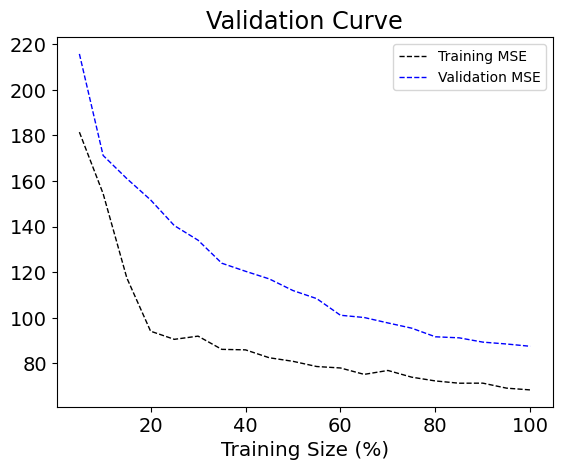

In [26]:
# supporting code and discussion
increments  = 5
train_errors, validation_errors = learning_curve(folds, 9, incr=increments)
plot_learning_curve(train_errors, validation_errors)

## Before You Submit...

1. Did you provide output exactly as requested?
2. Did you re-execute the entire notebook? ("Restart Kernel and Rull All Cells...")
3. If you did not complete the assignment or had difficulty please explain what gave you the most difficulty in the Markdown cell below.
4. Did you change the name of the file to `jhed_id.ipynb`?

Do not submit any other files.